In [1]:
import torch, numpy as np
import matplotlib.pyplot as plt
import json

from src.utils import DataType, NeuralOperatorDataset
from src.models import NeuralOperatorModel, ModelType

In [2]:
from src.utils import LpLoss

poly = 1
ranks = [1, 2, 4, 8, 16]

for r in ranks:
    model_name = f"rank{r}sweep_{poly}_fixed"

    with open(f'./models/{model_name}.json') as f:
        d = json.load(f)

    print(d)

    data_type = DataType(d["data"])

    data = NeuralOperatorDataset(data_type, 
                                is_cheby=False if d["model"] == "fno" else True, 
                                ntrain=d["ntrain"],
                                ntest=d["ntest"], 
                                batch_size=d["batch_size"], 
                                normalize=d["normalize"],
                                subsample=d["subsample"])


    model_params = {k: eval(v) for k, v in (arg.split('=') for arg in d["arg"])}
    model = NeuralOperatorModel(ModelType(d["model"]), data=data_type, **model_params)
    device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

    model.load_state_dict(torch.load(f"./models/{model_name}.pt", map_location=device))


    loss_fn = LpLoss(size_average=False)

    #Model Validation

    model.eval()
    model.to(device)
    test_l2 = 0.0
    with torch.no_grad():
        for x, y in data.test_loader:
            x, y = x.to(device), y.to(device)
            out = model(y)
            test_l2 += loss_fn(out, y)
        
        test_l2 /= (data.ntest * data.batch_size)

        print("{:.10f}".format(test_l2))
        

{'model': 'ultramatrix', 'data': 'ode1', 'run_name': 'rank1sweep_1_fixed', 'project_name': 'ODEUMatSweep', 'subsample': 1, 'arg': ['modes=12', 'ind=1', 'rank=1'], 'nepochs': 500, 'ntrain': 1000, 'ntest': 200, 'batch_size': 4, 'normalize': False, 'nparams': 60}
0.2296967357
{'model': 'ultramatrix', 'data': 'ode1', 'run_name': 'rank2sweep_1_fixed', 'project_name': 'ODEUMatSweep', 'subsample': 1, 'arg': ['modes=12', 'ind=1', 'rank=2'], 'nepochs': 500, 'ntrain': 1000, 'ntest': 200, 'batch_size': 4, 'normalize': False, 'nparams': 108}
0.2106428593
{'model': 'ultramatrix', 'data': 'ode1', 'run_name': 'rank4sweep_1_fixed', 'project_name': 'ODEUMatSweep', 'subsample': 1, 'arg': ['modes=12', 'ind=1', 'rank=4'], 'nepochs': 500, 'ntrain': 1000, 'ntest': 200, 'batch_size': 4, 'normalize': False, 'nparams': 204}
0.4087517858
{'model': 'ultramatrix', 'data': 'ode1', 'run_name': 'rank8sweep_1_fixed', 'project_name': 'ODEUMatSweep', 'subsample': 1, 'arg': ['modes=12', 'ind=1', 'rank=8'], 'nepochs': 50

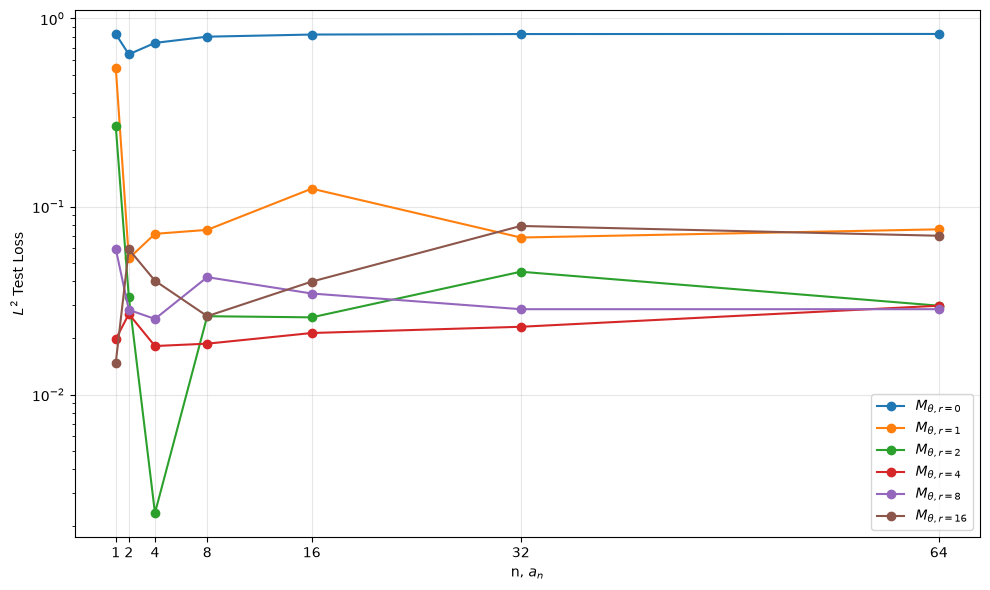

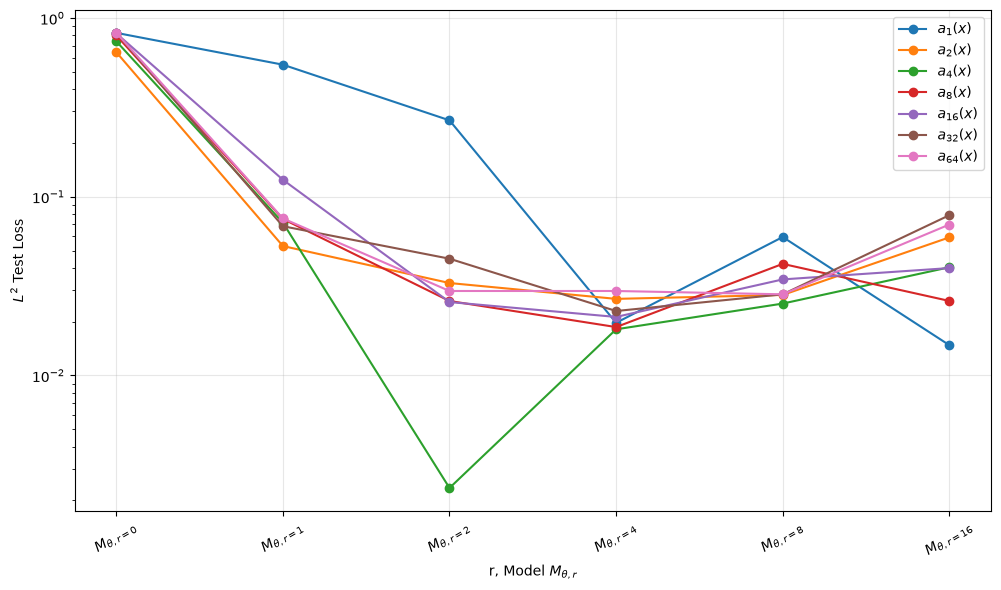

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Data
# ============================================================

indices = np.array([1, 2, 4, 8, 16, 32, 64])

# Rows
L_hat = np.array([
    0.00365, 0.00350, 0.00332, 0.00318,
    0.00311, 0.00310, 0.00310
])

M_theta_r0 = np.array([
    0.82646, 0.64458, 0.74165, 0.8003,
    0.82143, 0.82646, 0.82741
])

M_theta_r1 = np.array([
    0.54846, 0.053006, 0.071599, 0.07515,
    0.12449, 0.068429, 0.075651
])

M_theta_r2 = np.array([
    0.26772, 0.032909, 0.002347, 0.026114,
    0.025753, 0.045022, 0.029699
])

M_theta_r4 = np.array([
    0.019706, 0.02683, 0.018127, 0.018657,
    0.021259, 0.022945, 0.029699
])

M_theta_r8 = np.array([
    0.059541, 0.028222, 0.025255, 0.042119,
    0.03448, 0.028456, 0.028456
])

M_theta_r16 = np.array([
    0.014776, 0.059253, 0.040317, 0.026124,
    0.039899, 0.078847, 0.069933
])


# ============================================================
# Plot 1: Rows
# ============================================================

plt.figure(figsize=(10, 6))

# plt.plot(indices, L_hat, marker='o', label=r'$\hat{\mathcal{L}}$')
plt.plot(indices, M_theta_r0, marker='o', label=r'$M_{\theta,r=0}$')
plt.plot(indices, M_theta_r1, marker='o', label=r'$M_{\theta,r=1}$')
plt.plot(indices, M_theta_r2, marker='o', label=r'$M_{\theta,r=2}$')
plt.plot(indices, M_theta_r4, marker='o', label=r'$M_{\theta,r=4}$')
plt.plot(indices, M_theta_r8, marker='o', label=r'$M_{\theta,r=8}$')
plt.plot(indices, M_theta_r16, marker='o', label=r'$M_{\theta,r=16}$')

plt.yscale('log')
plt.xlabel(r'n, $a_n$')
plt.ylabel(r'$L^2$ Test Loss')
plt.xticks(indices)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()


# ============================================================
# Plot 2: Columns
# ============================================================

models = [
    r'$M_{\theta,r=0}$',
    r'$M_{\theta,r=1}$',
    r'$M_{\theta,r=2}$',
    r'$M_{\theta,r=4}$',
    r'$M_{\theta,r=8}$',
    r'$M_{\theta,r=16}$'
]

a_1 = np.array([ 0.82646, 0.54846, 0.26772, 0.019706, 0.059541, 0.014776])
a_2 = np.array([ 0.64458, 0.053006, 0.032909, 0.02683, 0.028222, 0.059253])
a_4 = np.array([ 0.74165, 0.071599, 0.002347, 0.018127, 0.025255, 0.040317])
a_8 = np.array([ 0.8003, 0.07515, 0.026114, 0.018657, 0.042119, 0.026124])
a_16 = np.array([ 0.82143, 0.12449, 0.025753, 0.021259, 0.03448, 0.039899])
a_32 = np.array([ 0.82646, 0.068429, 0.045022, 0.022945, 0.028456, 0.078847])
a_64 = np.array([ 0.82741, 0.075651, 0.029699, 0.029699, 0.028456, 0.069933])

plt.figure(figsize=(10, 6))

plt.plot(models, a_1, marker='o', label=r'$a_1(x)$')
plt.plot(models, a_2, marker='o', label=r'$a_2(x)$')
plt.plot(models, a_4, marker='o', label=r'$a_4(x)$')
plt.plot(models, a_8, marker='o', label=r'$a_8(x)$')
plt.plot(models, a_16, marker='o', label=r'$a_{16}(x)$')
plt.plot(models, a_32, marker='o', label=r'$a_{32}(x)$')
plt.plot(models, a_64, marker='o', label=r'$a_{64}(x)$')

plt.xlabel(r'r, Model $M_{\theta,r}$')
plt.ylabel(r'$L^2$ Test Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.yscale('log')
plt.show()



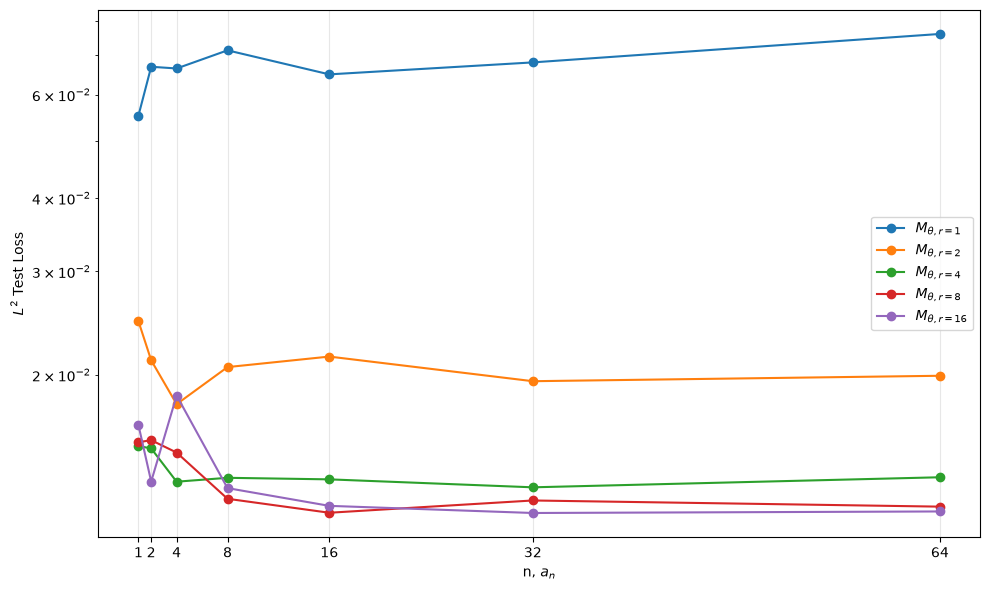

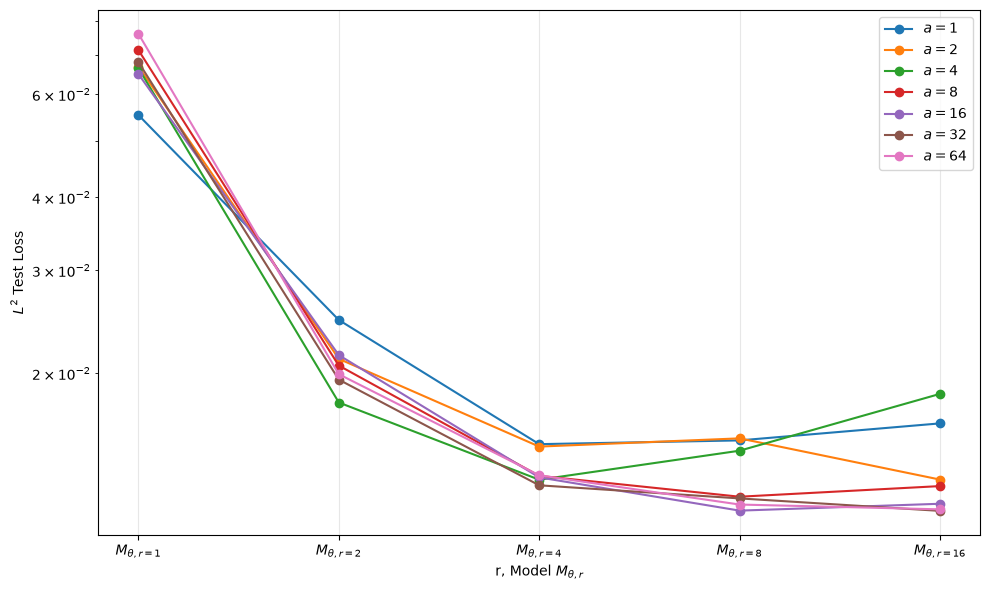

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Data
# ============================================================

indices = np.array([1, 2, 4, 8, 16, 32, 64])

# Rows
r1 = np.array([
    0.055276638641953466,
    0.06692495089024306,
    0.06647744618356227,
    0.07137666471302509,
    0.06495655588805675,
    0.06807909563183784,
    0.07611210860311984
])

r2 = np.array([
    0.024669609274715187,
    0.021170247234404086,
    0.01782640011049807,
    0.02061536265537143,
    0.021483550053089856,
    0.019505881294608115,
    0.019925843570381404
])

r4 = np.array([
    0.015129880188032985,
    0.014986320491880178,
    0.01315321191214025,
    0.013355882465839386,
    0.01327468415722251,
    0.012866914207115769,
    0.013384345937520265
])

r8 = np.array([
    0.015355378724634647,
    0.01547899231314659,
    0.014744924977421761,
    0.01230149006471038,
    0.011646009739488363,
    0.012219930356368423,
    0.01192831334657967
])

r16 = np.array([
    0.016418980602174997,
    0.013160964297130704,
    0.018440829813480376,
    0.012826909609138966,
    0.011965136444196105,
    0.011634775353595615,
    0.011705126445740462
])


# ============================================================
# Plot 1: Rows
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(indices, r1, marker='o', label=r'$M_{\theta,r=1}$')
plt.plot(indices, r2, marker='o', label=r'$M_{\theta,r=2}$')
plt.plot(indices, r4, marker='o', label=r'$M_{\theta,r=4}$')
plt.plot(indices, r8, marker='o', label=r'$M_{\theta,r=8}$')
plt.plot(indices, r16, marker='o', label=r'$M_{\theta,r=16}$')

plt.xlabel(r'n, $a_n$')
plt.ylabel(r'$L^2$ Test Loss')
plt.yscale('log')
plt.xticks(indices)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()


# ============================================================
# Plot 2: Columns
# ============================================================

models = [
    r'$M_{\theta,r=1}$',
    r'$M_{\theta,r=2}$',
    r'$M_{\theta,r=4}$',
    r'$M_{\theta,r=8}$',
    r'$M_{\theta,r=16}$'
]

a_1 = np.array([
    0.055276638641953466,
    0.024669609274715187,
    0.015129880188032985,
    0.015355378724634647,
    0.016418980602174997
])

a_2 = np.array([
    0.06692495089024306,
    0.021170247234404086,
    0.014986320491880178,
    0.01547899231314659,
    0.013160964297130704
])

a_4 = np.array([
    0.06647744618356227,
    0.01782640011049807,
    0.01315321191214025,
    0.014744924977421761,
    0.018440829813480376
])

a_8 = np.array([
    0.07137666471302509,
    0.02061536265537143,
    0.013355882465839386,
    0.01230149006471038,
    0.012826909609138966
])

a_16 = np.array([
    0.06495655588805675,
    0.021483550053089856,
    0.01327468415722251,
    0.011646009739488363,
    0.011965136444196105
])

a_32 = np.array([
    0.06807909563183784,
    0.019505881294608115,
    0.012866914207115769,
    0.012219930356368423,
    0.011634775353595615
])

a_64 = np.array([
    0.07611210860311984,
    0.019925843570381404,
    0.013384345937520265,
    0.01192831334657967,
    0.011705126445740462
])


plt.figure(figsize=(10, 6))

plt.plot(models, a_1, marker='o', label=r'$a=1$')
plt.plot(models, a_2, marker='o', label=r'$a=2$')
plt.plot(models, a_4, marker='o', label=r'$a=4$')
plt.plot(models, a_8, marker='o', label=r'$a=8$')
plt.plot(models, a_16, marker='o', label=r'$a=16$')
plt.plot(models, a_32, marker='o', label=r'$a=32$')
plt.plot(models, a_64, marker='o', label=r'$a=64$')

plt.xlabel(r'r, Model $M_{\theta,r}$')
plt.ylabel(r'$L^2$ Test Loss')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()